In [1]:
!pip install nltk
!pip install pandas
!pip install numpy
!pip install bs4
!pip install tensorflow
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import nltk
import numpy as np 
import pandas as pd 
import tensorflow as tf
from bs4 import BeautifulSoup
nltk.download('stopwords')
nltk.download('wordnet')

I0000 00:00:1781865015.444569    6180 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781865015.445138    6180 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781865015.478401    6180 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781865016.336312    6180 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

True

### Loading the dataset 

In [3]:
data = pd.read_csv("/home/rsh/Desktop/projects /sentiment_analysis_IMDB/dataset /IMDB Dataset.csv")

In [4]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### TEXT Preprocessing 

In [5]:
from nltk.tokenize import word_tokenize 
import string 
from nltk.stem import WordNetLemmatizer, PorterStemmer

In [6]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /home/rsh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/rsh/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
punctuations = string.punctuation
stopwords = nltk.corpus.stopwords.words('english')
lm = WordNetLemmatizer()
## stopwords

In [8]:
text =data['review'][1]

In [9]:
BeautifulSoup(text,"html.parser").get_text()

'A wonderful little production. The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams\' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master\'s of comedy and his life. The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional \'dream\' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell\'s murals decorating every surface) are terribly well done.'

In [10]:
nltk.download('punkt_tab') ### required for tokenization 

[nltk_data] Downloading package punkt_tab to /home/rsh/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [11]:
def clean_text(text):
    only_text = BeautifulSoup(text, "html.parser").get_text() ## removed the html tags 
    text = "".join([char.lower() for char in only_text if char not in punctuations]) ## lower the text and remove punctuations 
    tokens = word_tokenize(text)
    final_text= " ".join([lm.lemmatize(token) for token in tokens if token not in stopwords ]) ## stopword remove and lemmatization 
    return final_text



In [12]:
clean_text("worth it ")

'worth'

In [13]:
## exclude negative words form stopwords 

##stopwords = nltk.corpus.stopwords.words('english')
##negations = {"not", "no", "nor", "don", "didn", "doesn", "isn", "wasn", "wouldn", "couldn", "shouldn", "won", "aren", "weren", "hasn", "haven", "hadn"}
##stopwords = [word for word in stopwords if word not in negations]

In [14]:

##sample_texts = ["Not worth it", "This was not good", "I really liked it", "It wasn't bad at all"]
##for t in sample_texts:     
##    print(t, "->", clean_text(t))


In [15]:
clean_text(text)

'wonderful little production filming technique unassuming oldtimebbc fashion give comforting sometimes discomforting sense realism entire piece actor extremely well chosen michael sheen got polari voice pat truly see seamless editing guided reference williams diary entry well worth watching terrificly written performed piece masterful production one great master comedy life realism really come home little thing fantasy guard rather use traditional dream technique remains solid disappears play knowledge sens particularly scene concerning orton halliwell set particularly flat halliwells mural decorating every surface terribly well done'

In [16]:
X= data['review'].apply(lambda x : clean_text(x))

In [17]:
X


0        one reviewer mentioned watching 1 oz episode y...
1        wonderful little production filming technique ...
2        thought wonderful way spend time hot summer we...
3        basically there family little boy jake think t...
4        petter matteis love time money visually stunni...
                               ...                        
49995    thought movie right good job wasnt creative or...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary school nu...
49998    im going disagree previous comment side maltin...
49999    one expects star trek movie high art fan expec...
Name: review, Length: 50000, dtype: object

In [18]:
Y = data['sentiment'].apply(lambda x :1 if x =='positive' else 0)

In [19]:
Y

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int64

In [20]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [21]:
## split data into train and test data 
from sklearn.model_selection import train_test_split
X_train,X_test , Y_train, Y_test= train_test_split(X, Y , test_size=.25)

In [22]:
X_train.shape


(37500,)

In [23]:
Y_train = np.array(Y_train, dtype=np.int32)
Y_test = np.array(Y_test, dtype=np.int32)

### Text Vectorization 

In [24]:
from tensorflow.keras.layers import TextVectorization


In [25]:
vocab_size= 20000
max_length=200

vectorize_layer = TextVectorization(
    max_tokens = vocab_size, 
    output_mode = 'int',
    output_sequence_length= max_length
)

E0000 00:00:1781865066.523559    6180 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1781865066.540960    6180 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [26]:
## Build vocabulary 

vectorize_layer.adapt(np.array(X_train))

In [27]:
vocab = np.array(vectorize_layer.get_vocabulary())
vocab[:50]

array(['', '[UNK]', 'movie', 'film', 'one', 'like', 'time', 'good',
       'character', 'get', 'even', 'story', 'would', 'make', 'see',
       'really', 'scene', 'much', 'well', 'people', 'great', 'bad',
       'also', 'first', 'show', 'dont', 'way', 'thing', 'made', 'could',
       'think', 'life', 'go', 'know', 'watch', 'love', 'many', 'seen',
       'actor', 'plot', 'say', 'two', 'never', 'look', 'acting', 'end',
       'little', 'best', 'year', 'ever'], dtype='<U18')

In [28]:
vocab.shape

(20000,)

In [29]:
vectorize_training_set = vectorize_layer(X_train)

In [30]:
X_train.shape

(37500,)

In [31]:
vectorize_training_set.shape

TensorShape([37500, 200])

In [32]:
vectorize_training_set

<tf.Tensor: shape=(37500, 200), dtype=int64, numpy=
array([[   2,  123, 3259, ...,    0,    0,    0],
       [5313,  175, 1194, ...,    0,    0,    0],
       [   5, 3606,   30, ...,    0,    0,    0],
       ...,
       [6565,    1,   20, ...,   20, 2253,  616],
       [ 147, 1515, 1487, ...,    0,    0,    0],
       [ 707,   42,  452, ...,    0,    0,    0]], shape=(37500, 200))>

In [33]:
X_train.to_list()[2]

'like hack think lone ranger reincarnated 2000s cab driver decent flawed guy philadelphia best seeking work issue troubled past youve got synopsis david morse nearly perfect olshansky help people instead riding silver old west drive cab mean street contemporary philly without handing silver bullet supporting cast first class well average time witty dialog almost reach level 70 classic series rockford file show deserves return hopefully better time slot 9pm fridayeastern'

In [34]:
vectorize_training_set[2,:]

<tf.Tensor: shape=(200,), dtype=int64, numpy=
array([    5,  3606,    30,  3134,  2831, 12329, 13183,  5534,  1716,
         437,  2670,    70,  7629,    47,  2753,    55,   690,  2845,
         397,   695,    92,  4198,   511,  8498,   670,   303,     1,
         199,    19,   212,  2868,  2502,    83,  1113,   970,  5534,
         180,   551,  1907, 16913,   118, 14515,  2502,  2106,   621,
          87,    23,   593,    18,   758,     6,  1736,   515,   121,
        1430,   439,   760,   226,   129, 13269,  4892,    24,   861,
         558,  2057,    52,     6,  7443,     1,     1,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,   

In [35]:
np.where(vocab=='cockchasing')

(array([], dtype=int64),)

In [36]:
X_train_tf = tf.constant(X_train, dtype=tf.string)
X_test_tf = tf.constant(X_test, dtype=tf.string)

### Building Embedding Layer

In [37]:
from tensorflow.keras.layers import Embedding
embed = Embedding(
    input_dim=len(vocab),
    output_dim=100
)

In [38]:
embed(vectorize_training_set[2,:])

<tf.Tensor: shape=(200, 100), dtype=float32, numpy=
array([[ 0.01132264, -0.00250366,  0.00426916, ..., -0.01834822,
         0.02260572, -0.0069107 ],
       [-0.03629864,  0.01732048, -0.03424772, ..., -0.04984055,
         0.01730288,  0.04895593],
       [-0.0100291 , -0.03604484,  0.03223828, ..., -0.00910491,
        -0.03761532, -0.04051466],
       ...,
       [-0.03798801,  0.03050189,  0.00758266, ..., -0.00343224,
        -0.0284424 ,  0.04427492],
       [-0.03798801,  0.03050189,  0.00758266, ..., -0.00343224,
        -0.0284424 ,  0.04427492],
       [-0.03798801,  0.03050189,  0.00758266, ..., -0.00343224,
        -0.0284424 ,  0.04427492]], shape=(200, 100), dtype=float32)>

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import Input
from tensorflow.keras.layers import LSTM, Dense,Dropout

model = Sequential()
model.add(tf.keras.Input(shape=(),dtype=tf.string))

model.add(vectorize_layer)
model.add(Embedding(input_dim=vocab_size,output_dim= 100,mask_zero=True))
model.add(LSTM(100))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,086,929 (7.96 MB)

 Trainable params: 2,086,929 (7.96 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

### Model Training 

In [41]:
from tensorflow.keras.callbacks import EarlyStopping



early_stop= EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True

)

history = model.fit(
    X_train_tf, Y_train,
    validation_data=(X_test_tf, Y_test),
    batch_size=32,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
   3/1172 ━━━━━━━━━━━━━━━━━━━━ 56s 48ms/step - accuracy: 0.6111 - loss: 0.6924

E0000 00:00:1781865068.998654    6180 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


1172/1172 ━━━━━━━━━━━━━━━━━━━━ 57s 48ms/step - accuracy: 0.8345 - loss: 0.3782 - val_accuracy: 0.8902 - val_loss: 0.2856
Epoch 2/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 57s 49ms/step - accuracy: 0.9213 - loss: 0.2145 - val_accuracy: 0.8890 - val_loss: 0.2812
Epoch 3/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 56s 48ms/step - accuracy: 0.9481 - loss: 0.1452 - val_accuracy: 0.8818 - val_loss: 0.3253
Epoch 4/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 56s 48ms/step - accuracy: 0.9677 - loss: 0.0939 - val_accuracy: 0.8701 - val_loss: 0.4490
Epoch 5/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 56s 48ms/step - accuracy: 0.9809 - loss: 0.0578 - val_accuracy: 0.8616 - val_loss: 0.4827
Epoch 6/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 57s 49ms/step - accuracy: 0.9822 - loss: 0.0516 - val_accuracy: 0.8701 - val_loss: 0.5795


In [42]:
model.save("/home/rsh/Desktop/projects /sentiment_analysis_IMDB/models/sentiment_classifier_1.keras")

### Accuracy Visualisation 

In [43]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

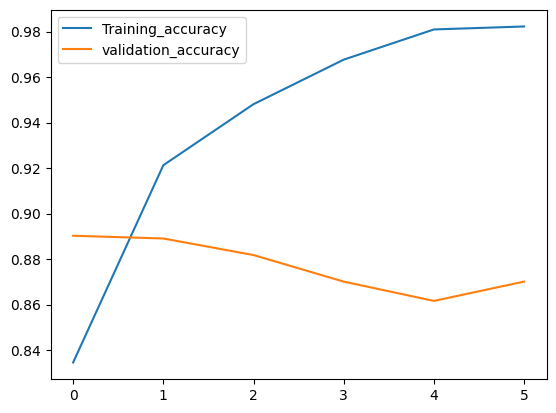

In [44]:
import matplotlib.pyplot as plt 
plt.plot(history.history['accuracy'], label ="Training_accuracy")
plt.plot(history.history['val_accuracy'], label ="validation_accuracy")
plt.legend()
plt.show()

In [45]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,260,789 (23.88 MB)

 Trainable params: 2,086,929 (7.96 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,173,860 (15.92 MB)

### Testing Model on random test 

In [46]:
print(model.input_shape)
print(model.inputs)

(None,)
[<KerasTensor shape=(None,), dtype=string, sparse=False, ragged=False, name=keras_tensor>]


In [47]:


sample = tf.constant(
    ["movie was good , but i didnt like the ending  "],
    dtype=tf.string
)


prediction = model.predict(sample)
if prediction>0.5 :
    print("Positive Sentiment,""\nscore : ",prediction[0][0])
else :
    print("Negative Sentiment," "\nscore : ",prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Negative Sentiment,
score :  0.35076073


In [48]:


sample_2 = tf.constant(
    ["movie was good  "],
    dtype=tf.string
)


prediction = model.predict(sample_2)
if prediction>0.5 :
    print("Positive Sentiment,""\nscore : ",prediction[0][0])
else :
    print("Negative Sentiment," "\nscore : ",prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Negative Sentiment,
score :  0.44674268


In [49]:
print(vectorize_layer(["not worth it"]).numpy()[0][:5])
print(vectorize_layer(["worth it"]).numpy()[0][:5])
print("not" in vocab)

[  1 186   1   0   0]
[186   1   0   0   0]
False


In [50]:
## so it is giving positive sentiment for both of the cases 

In [51]:
## Model Evaluation 

 ## precision , recall, F1 score ,confusion matrix 

In [52]:
type(X_train)

pandas.core.series.Series

In [53]:
y_pred = model.predict(X_test_tf)


391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step


In [54]:
y_pred_binary = np.where(y_pred>0.5,1,0)
y_pred_binary

array([[0],
       [1],
       [0],
       ...,
       [1],
       [1],
       [0]], shape=(12500, 1))

In [55]:
y_pred_binary.shape

(12500, 1)

In [56]:
y_true = np.array(Y_test)
y_pred_flat = y_pred_binary.flatten()

In [57]:
y_true


array([0, 1, 0, ..., 1, 1, 0], shape=(12500,), dtype=int32)

In [58]:
y_pred_flat

array([0, 1, 0, ..., 1, 1, 0], shape=(12500,))

In [59]:
y_true.shape



(12500,)

In [60]:
y_pred_flat.shape

(12500,)

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      6320
           1       0.90      0.88      0.89      6180

    accuracy                           0.89     12500
   macro avg       0.89      0.89      0.89     12500
weighted avg       0.89      0.89      0.89     12500



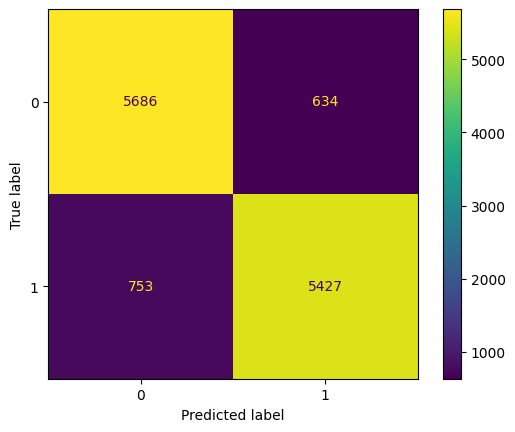

In [61]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_true, y_pred_flat))
disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred_flat))
disp.plot()